In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import os
import cv2
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import *

from sklearn.svm import SVC

from skimage.feature import hog

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications import VGG16

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobile_preprocess
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess

from tensorflow.keras.models import Model

In [3]:
# ==========================================================
# IMPORTS
# ==========================================================

import os
import cv2
import random
import warnings
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from collections import Counter

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

plt.style.use("ggplot")

In [4]:
emotion_map = {
    "angry":0,
    "disgust":1,
    "fear":2,
    "happy":3,
    "sad":4,
    "surprise":5
}

emotion_names = [
    "Angry",
    "Disgust",
    "Fear",
    "Happy",
    "Sad",
    "Surprise"
]

In [5]:
# ==========================================================
# COMMON SETTINGS
# ==========================================================

IMG_SIZE = 128

emotion_names = [
    "Angry",
    "Disgust",
    "Fear",
    "Happy",
    "Sad",
    "Surprise"
]

N_CLASSES = 6

In [6]:
# ==========================================================
# LOAD JAFFE
# ==========================================================

jaffe_data = []
jaffe_labels = []

emotion_map_jaffe = {
    'AN':0,
    'DI':1,
    'FE':2,
    'HA':3,
    'SA':4,
    'SU':5
}

jaffe_path = "/kaggle/input/datasets/navneet0094/data-jafe/jaffe"

for img_name in sorted(os.listdir(jaffe_path)):

    try:

        emotion = img_name.split(".")[1][:2]

        if emotion not in emotion_map_jaffe:
            continue

        img_path = os.path.join(
            jaffe_path,
            img_name
        )

        img = cv2.imread(
            img_path,
            cv2.IMREAD_GRAYSCALE
        )

        if img is None:
            continue

        img = cv2.resize(
            img,
            (IMG_SIZE, IMG_SIZE)
        )

        jaffe_data.append(img)
        jaffe_labels.append(
            emotion_map_jaffe[emotion]
        )

    except:
        pass

jaffe_data = np.array(jaffe_data)
jaffe_labels = np.array(jaffe_labels)

print("JAFFE :", jaffe_data.shape)

JAFFE : (183, 128, 128)


In [7]:
# ==========================================================
# LOAD CK+
# ==========================================================

ck_data = []
ck_labels = []

emotion_map_ck = {
    "anger":0,
    "disgust":1,
    "fear":2,
    "happy":3,
    "sadness":4,
    "surprise":5
}

ck_path = "/kaggle/input/datasets/shawon10/ckplus/CK+48"

MAX_PER_CLASS = 120

for emotion in emotion_map_ck.keys():

    emotion_path = os.path.join(
        ck_path,
        emotion
    )

    images = os.listdir(emotion_path)

    selected = random.sample(
        images,
        min(MAX_PER_CLASS, len(images))
    )

    for img_name in selected:

        img_path = os.path.join(
            emotion_path,
            img_name
        )

        img = cv2.imread(
            img_path,
            cv2.IMREAD_GRAYSCALE
        )

        if img is None:
            continue

        img = cv2.resize(
            img,
            (IMG_SIZE, IMG_SIZE)
        )

        ck_data.append(img)

        ck_labels.append(
            emotion_map_ck[emotion]
        )

ck_data = np.array(ck_data)
ck_labels = np.array(ck_labels)

print("CK+ :", ck_data.shape)

CK+ : (639, 128, 128)


In [8]:
# ==========================================================
# LOAD KDEF
# ==========================================================

kdef_data = []
kdef_labels = []

emotion_map_kdef = {
    'AN':0,
    'DI':1,
    'AF':2,
    'HA':3,
    'SA':4,
    'SU':5
}

MAX_PER_CLASS = 120

kdef_path = "/kaggle/input/datasets/navneet0094/da-kdef/KDEF_and_AKDEF/KDEF"

counter = Counter()

for folder in os.listdir(kdef_path):

    folder_path = os.path.join(
        kdef_path,
        folder
    )

    if not os.path.isdir(folder_path):
        continue

    for img_name in os.listdir(folder_path):

        if not img_name.endswith(".JPG"):
            continue

        emotion = img_name[4:6]

        if emotion not in emotion_map_kdef:
            continue

        label = emotion_map_kdef[emotion]

        if counter[label] >= MAX_PER_CLASS:
            continue

        img_path = os.path.join(
            folder_path,
            img_name
        )

        img = cv2.imread(
            img_path,
            cv2.IMREAD_GRAYSCALE
        )

        if img is None:
            continue

        img = cv2.resize(
            img,
            (IMG_SIZE, IMG_SIZE)
        )

        kdef_data.append(img)
        kdef_labels.append(label)

        counter[label] += 1

kdef_data = np.array(kdef_data)
kdef_labels = np.array(kdef_labels)

print("KDEF :", kdef_data.shape)

KDEF : (720, 128, 128)


In [9]:
# ==========================================================
# LOAD RAFDB TEST SET
# ==========================================================

raf_data = []
raf_labels = []

emotion_map_raf = {
    'angry':0,
    'disgust':1,
    'fear':2,
    'happy':3,
    'sad':4,
    'surprise':5
}

raf_test_path = "/kaggle/input/datasets/dollyprajapati182/balanced-raf-db-dataset-7575-grayscale/test"

MAX_PER_CLASS = 200

for emotion in emotion_map_raf.keys():

    folder = os.path.join(
        raf_test_path,
        emotion
    )

    images = os.listdir(folder)

    selected = random.sample(
        images,
        min(MAX_PER_CLASS, len(images))
    )

    for img_name in selected:

        img_path = os.path.join(
            folder,
            img_name
        )

        img = cv2.imread(
            img_path,
            cv2.IMREAD_GRAYSCALE
        )

        if img is None:
            continue

        img = cv2.resize(
            img,
            (128,128)
        )

        raf_data.append(img)

        raf_labels.append(
            emotion_map_raf[emotion]
        )

raf_data = np.array(raf_data)
raf_labels = np.array(raf_labels)

print("RAFDB :", raf_data.shape)

RAFDB : (1200, 128, 128)


In [10]:
# ==========================================================
# COMBINE SOURCE DATASETS
# ==========================================================

X_train_gray = np.concatenate([
    jaffe_data,
    ck_data,
    kdef_data
])

y_train = np.concatenate([
    jaffe_labels,
    ck_labels,
    kdef_labels
])

X_test_gray = raf_data
y_test = raf_labels

print()
print("TRAIN :", X_train_gray.shape)
print("TEST  :", X_test_gray.shape)


TRAIN : (1542, 128, 128)
TEST  : (1200, 128, 128)


In [11]:
# ==========================================================
# DATASET STATISTICS
# ==========================================================

stats = pd.DataFrame({

    "Dataset":[
        "JAFFE",
        "CK+",
        "KDEF",
        "RAFDB"
    ],

    "Images":[
        len(jaffe_data),
        len(ck_data),
        len(kdef_data),
        len(raf_data)
    ]
})

stats

,Dataset,Images
0,JAFFE,183
1,CK+,639
2,KDEF,720
3,RAFDB,1200


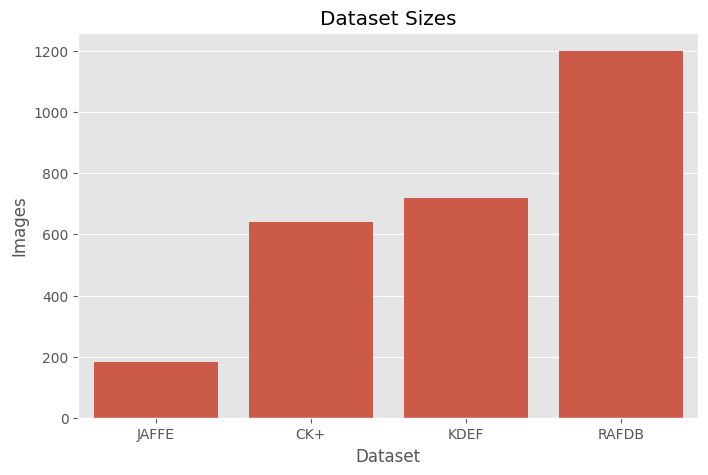

In [12]:
# ==========================================================
# DATASET SIZE
# ==========================================================

plt.figure(figsize=(8,5))

sns.barplot(
    x="Dataset",
    y="Images",
    data=stats
)

plt.title(
    "Dataset Sizes"
)

plt.show()

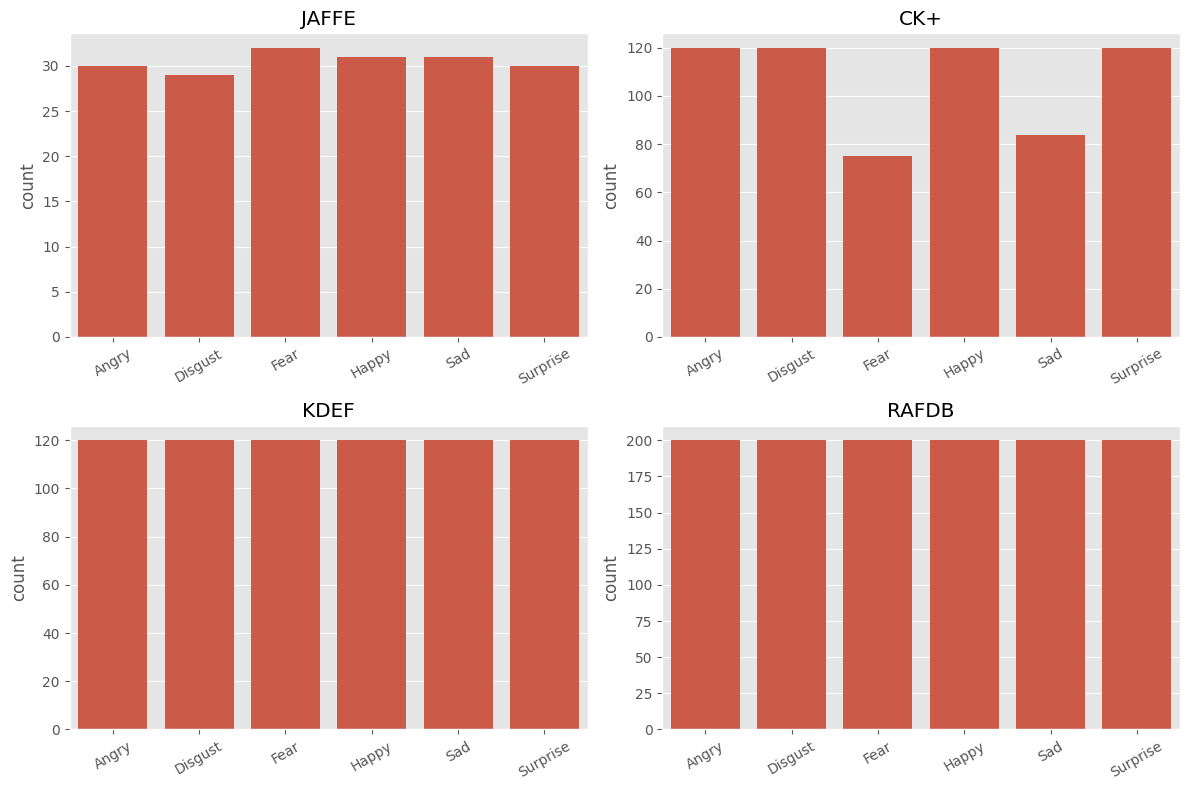

In [13]:
# ==========================================================
# CLASS DISTRIBUTION
# ==========================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12,8)
)

datasets = [

    ("JAFFE",jaffe_labels),

    ("CK+",ck_labels),

    ("KDEF",kdef_labels),

    ("RAFDB",raf_labels)
]

for ax,(name,labels) in zip(
    axes.ravel(),
    datasets
):

    sns.countplot(
        x=labels,
        ax=ax
    )

    ax.set_title(name)

    ax.set_xticklabels(
        emotion_names,
        rotation=30
    )

plt.tight_layout()
plt.show()

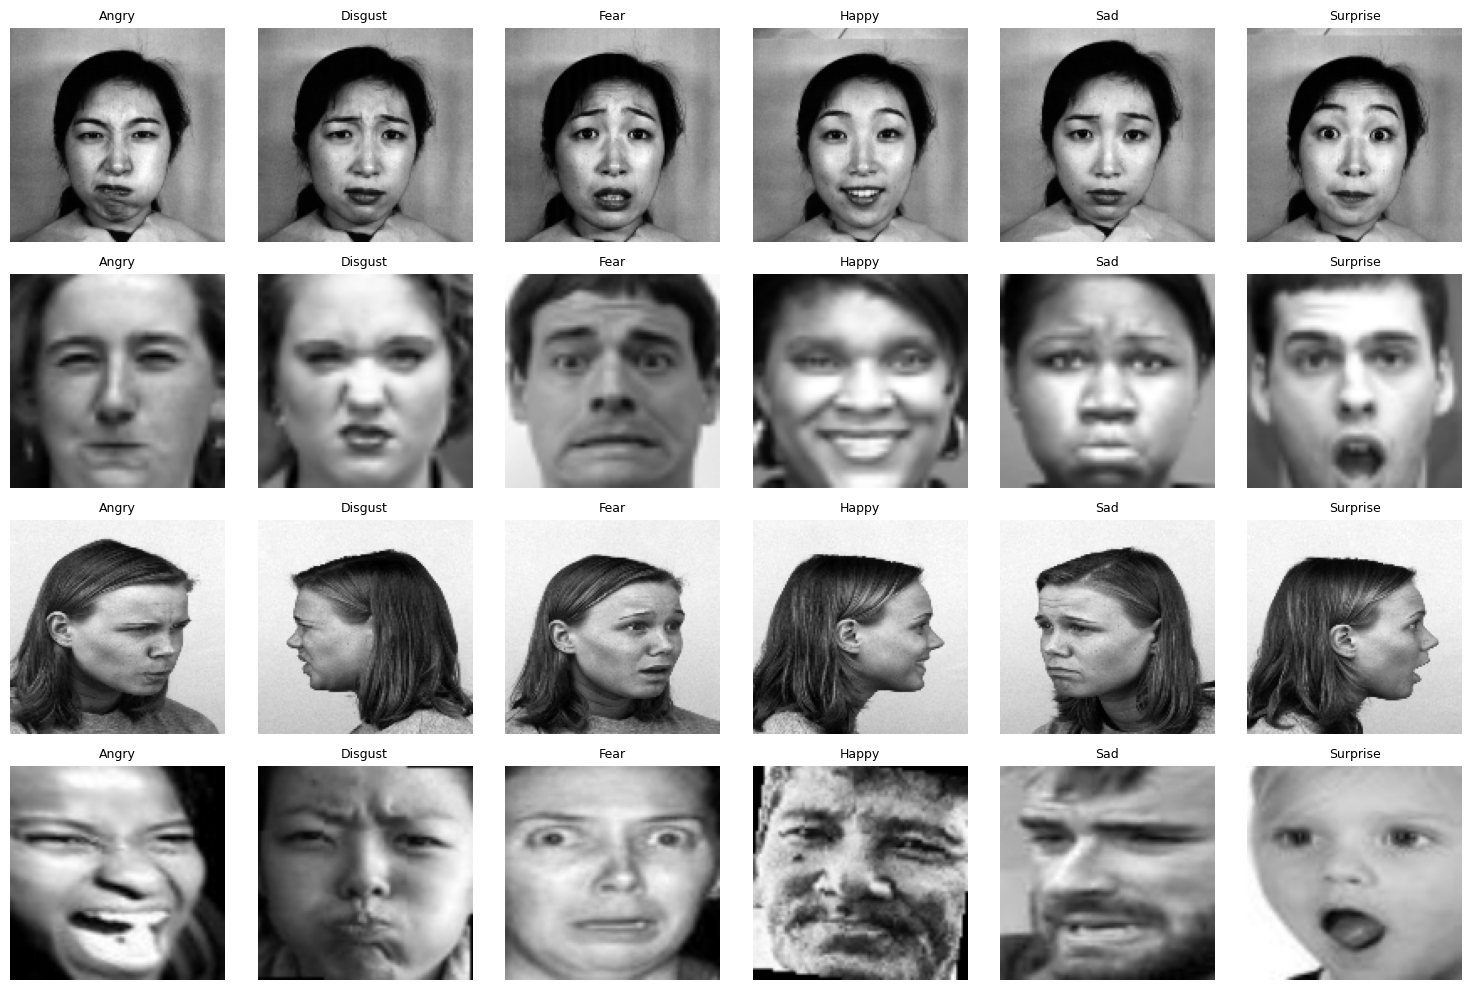

In [14]:
# ==========================================================
# SAMPLE VISUALIZATION
# ==========================================================

datasets = {

    "JAFFE":(
        jaffe_data,
        jaffe_labels
    ),

    "CK+":(
        ck_data,
        ck_labels
    ),

    "KDEF":(
        kdef_data,
        kdef_labels
    ),

    "RAFDB":(
        raf_data,
        raf_labels
    )
}

fig, axes = plt.subplots(
    4,
    6,
    figsize=(15,10)
)

for row,(dataset_name,(X,y)) in enumerate(
    datasets.items()
):

    for emotion in range(6):

        idx = np.where(
            y == emotion
        )[0][0]

        axes[row,emotion].imshow(
            X[idx],
            cmap="gray"
        )

        axes[row,emotion].set_title(
            emotion_names[emotion],
            fontsize=9
        )

        axes[row,emotion].axis("off")

        if emotion == 0:

            axes[row,emotion].set_ylabel(
                dataset_name,
                fontsize=12
            )

plt.tight_layout()
plt.show()

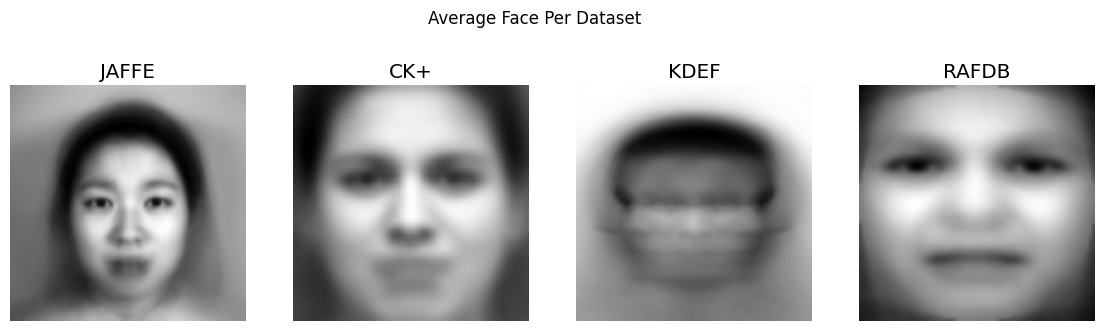

In [15]:
# ==========================================================
# DOMAIN GAP
# ==========================================================

fig,axes = plt.subplots(
    1,
    4,
    figsize=(14,4)
)

datasets = [
    ("JAFFE",jaffe_data),
    ("CK+",ck_data),
    ("KDEF",kdef_data),
    ("RAFDB",raf_data)
]

for ax,(name,data) in zip(
    axes,
    datasets
):

    ax.imshow(
        np.mean(data,axis=0),
        cmap="gray"
    )

    ax.set_title(name)

    ax.axis("off")

plt.suptitle(
    "Average Face Per Dataset"
)

plt.show()

In [16]:
X_test_gray = raf_data
y_test = raf_labels

print("Train :", X_train_gray.shape)
print("Test  :", X_test_gray.shape)

Train : (1542, 128, 128)
Test  : (1200, 128, 128)


In [17]:
# ==========================================================
# RGB CONVERSION
# ==========================================================

def gray_to_rgb(images):

    rgb_images = []

    for img in images:

        img = cv2.resize(
            img,
            (224,224)
        )

        rgb = cv2.cvtColor(
            img,
            cv2.COLOR_GRAY2RGB
        )

        rgb_images.append(rgb)

    return np.array(rgb_images)

In [18]:
X_train_rgb = gray_to_rgb(
    X_train_gray
)

X_test_rgb = gray_to_rgb(
    X_test_gray
)

print(X_train_rgb.shape)
print(X_test_rgb.shape)

(1542, 224, 224, 3)
(1200, 224, 224, 3)


In [19]:
from skimage.feature import hog
# ==========================================================
# HOG FEATURES
# ==========================================================

def extract_hog(images):

    hog_features = []

    for img in tqdm(images):

        feat = hog(
            img,
            orientations=9,
            pixels_per_cell=(8,8),
            cells_per_block=(2,2),
            block_norm='L2-Hys'
        )

        hog_features.append(feat)

    return np.array(hog_features)

In [20]:
X_train_hog = extract_hog(X_train_gray)

X_test_hog = extract_hog(X_test_gray)

print(X_train_hog.shape)
print(X_test_hog.shape)

100%|██████████| 1200/1200 [00:06<00:00, 175.38it/s]

(1542, 8100)
(1200, 8100)


In [21]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [22]:
mobile_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    pooling='avg'
)

I0000 00:00:1783325110.617096      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783325110.619910      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [23]:
# MOBILENET FEATURES

def extract_mobile(images):

    images = preprocess_input(
        images.astype(np.float32)
    )

    features = mobile_model.predict(
        images,
        batch_size=32,
        verbose=1
    )

    return features

In [24]:
X_train_mobile = extract_mobile(
    X_train_rgb
)

X_test_mobile = extract_mobile(
    X_test_rgb
)

print()
print(X_train_mobile.shape)
print(X_test_mobile.shape)

2026-07-06 08:05:25.927929: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-06 08:05:26.065259: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1783325127.480517      74 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


47/49 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

2026-07-06 08:05:38.225824: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-06 08:05:38.365454: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


49/49 ━━━━━━━━━━━━━━━━━━━━ 25s 255ms/step
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step

2026-07-06 08:05:51.307945: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-06 08:05:51.457187: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-06 08:05:51.594289: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 301ms/step

(1542, 1280)
(1200, 1280)


In [25]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

In [26]:
vgg_model = VGG16(
    weights='imagenet',
    include_top=False,
    pooling='avg'
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [27]:
# ==========================================================
# VGG FEATURES
# ==========================================================

def extract_vgg(images):

    images = preprocess_input(
        images.astype(np.float32)
    )

    features = vgg_model.predict(
        images,
        batch_size=32,
        verbose=1
    )

    return features

In [28]:
X_train_vgg = extract_vgg(
    X_train_rgb
)

X_test_vgg = extract_vgg(
    X_test_rgb
)

print()
print(X_train_vgg.shape)
print(X_test_vgg.shape)

49/49 ━━━━━━━━━━━━━━━━━━━━ 22s 223ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 330ms/step

(1542, 512)
(1200, 512)


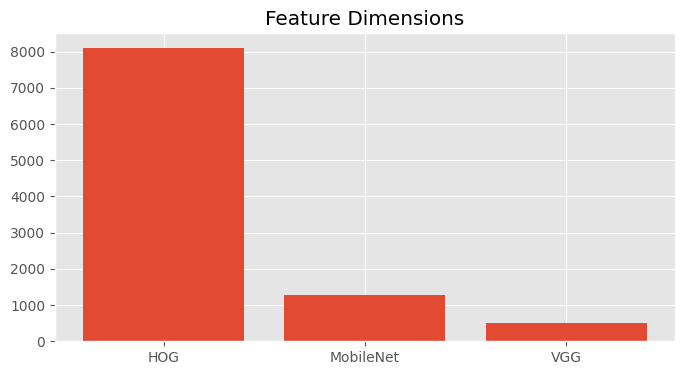

In [29]:
plt.figure(figsize=(8,4))

plt.bar(
    ["HOG","MobileNet","VGG"],
    [
        X_train_hog.shape[1],
        X_train_mobile.shape[1],
        X_train_vgg.shape[1]
    ]
)

plt.title(
    "Feature Dimensions"
)

plt.show()

In [30]:
from sklearn.decomposition import PCA

In [31]:
from sklearn.preprocessing import StandardScaler

In [32]:
X_train_hog = extract_hog(X_train_gray)

X_test_hog = extract_hog(X_test_gray)

print(X_train_hog.shape)
print(X_test_hog.shape)

100%|██████████| 1200/1200 [00:06<00:00, 176.00it/s]

(1542, 8100)
(1200, 8100)


In [33]:
scaler_mobile = StandardScaler()

X_train_mobile = scaler_mobile.fit_transform(X_train_mobile)
X_test_mobile = scaler_mobile.transform(X_test_mobile)

In [34]:
scaler_vgg = StandardScaler()

X_train_vgg = scaler_vgg.fit_transform(X_train_vgg)
X_test_vgg = scaler_vgg.transform(X_test_vgg)

In [35]:
X_train_fused = np.hstack([

    0.6 * X_train_hog,

    0.3 * X_train_mobile,

    0.1 * X_train_vgg

])

X_test_fused = np.hstack([

    0.6 * X_test_hog,

    0.3 * X_test_mobile,

    0.1 * X_test_vgg

])

In [36]:
print(X_train_fused.shape)
print(X_test_fused.shape)

(1542, 9892)
(1200, 9892)


In [37]:
from sklearn.decomposition import PCA

# pca = PCA(
#     n_components=200,
#     random_state=42  # only 80 % varience retained
# )
pca = PCA(
    n_components=0.95,
    random_state=42
)

In [38]:
X_train_pca = pca.fit_transform(
    X_train_fused
)

X_test_pca = pca.transform(
    X_test_fused
)
print(X_train_pca.shape)

(1542, 613)


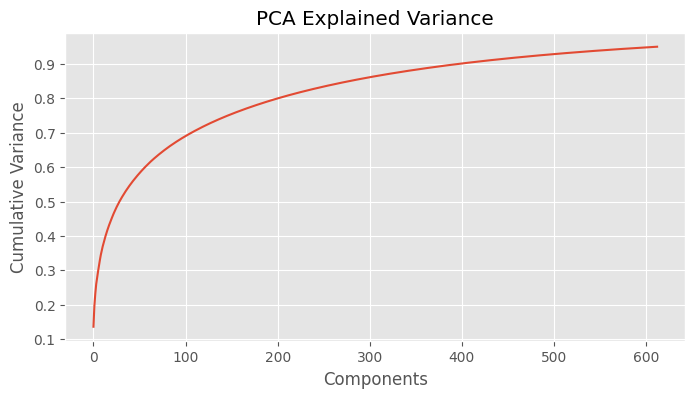

In [39]:
plt.figure(figsize=(8,4))

plt.plot(
    np.cumsum(
        pca.explained_variance_ratio_
    )
)

plt.xlabel("Components")
plt.ylabel("Cumulative Variance")

plt.title(
    "PCA Explained Variance"
)

plt.show()

In [40]:
from sklearn.manifold import TSNE

In [41]:
source_idx = np.random.choice(
    len(X_train_pca),
    500,
    replace=False
)

target_idx = np.random.choice(
    len(X_test_pca),
    500,
    replace=False
)

In [42]:
combined = np.vstack([

    X_train_pca[source_idx],

    X_test_pca[target_idx]

])

domain = np.array(
    [0]*500 +
    [1]*500
)

In [43]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

emb = tsne.fit_transform(combined)

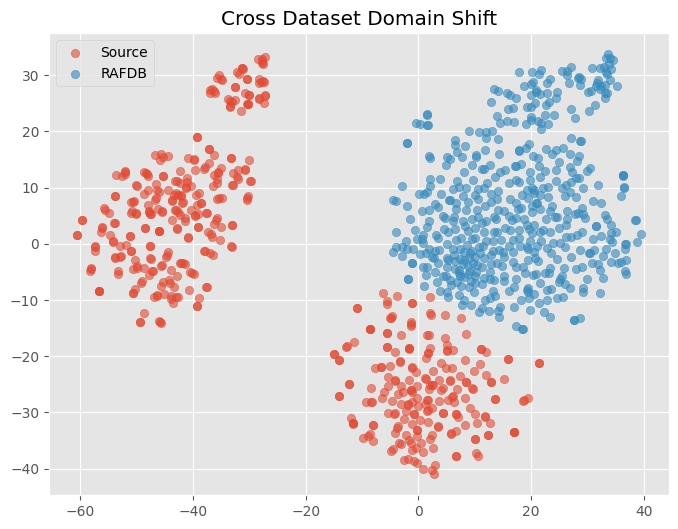

In [44]:
plt.figure(figsize=(8,6))

plt.scatter(
    emb[domain==0,0],
    emb[domain==0,1],
    alpha=0.6,
    label="Source"
)

plt.scatter(
    emb[domain==1,0],
    emb[domain==1,1],
    alpha=0.6,
    label="RAFDB"
)

plt.legend()

plt.title(
    "Cross Dataset Domain Shift"
)

plt.show()

In [45]:
from sklearn.svm import SVC

svm = SVC(
    kernel='rbf',
    C=10,
    gamma='scale'
)

svm.fit(
    X_train_pca,
    y_train
)

SVC(C=10)

In [46]:
pred = svm.predict(
    X_test_pca
)

In [47]:
from sklearn.metrics import *

acc = accuracy_score(
    y_test,
    pred
)

f1 = f1_score(
    y_test,
    pred,
    average='macro'
)

print("Accuracy :",acc)
print("Macro F1 :",f1)


Accuracy : 0.22416666666666665
Macro F1 : 0.19052975822129636


In [48]:
print(X_train_hog.shape)
print(X_test_hog.shape)
print(X_train_fused.shape)


(1542, 8100)
(1200, 8100)
(1542, 9892)


In [49]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        pred,
        target_names=emotion_names
    )
)

              precision    recall  f1-score   support

       Angry       0.17      0.68      0.28       200
     Disgust       0.31      0.12      0.17       200
        Fear       0.23      0.14      0.17       200
       Happy       0.31      0.28      0.30       200
         Sad       0.38      0.04      0.07       200
    Surprise       0.68      0.09      0.15       200

    accuracy                           0.22      1200
   macro avg       0.35      0.22      0.19      1200
weighted avg       0.35      0.22      0.19      1200



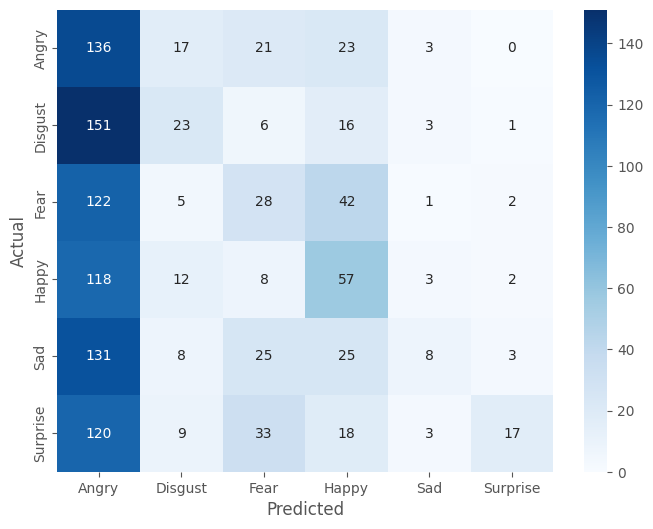

In [50]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=emotion_names,
    yticklabels=emotion_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()